In [3]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

from brainspace.utils.parcellation import map_to_labels, reduce_by_labels
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import pingouin

bids_folder_numrisk = '/mnt_04/ds-numrisk' 
bids_folder_dnumrisk = '/mnt_03/ds-dnumrisk'

In [4]:
from utils_02 import get_behave_bauer_params

df_behave_dyscalc = get_behave_bauer_params(bids_folder=bids_folder_dnumrisk, dataset='dyscalc',unbiased=True)
df_behave_mig = get_behave_bauer_params(bids_folder=bids_folder_numrisk, dataset='miguel',unbiased=True)

df_behave = pd.concat([df_behave_mig, df_behave_dyscalc])
df_behave = df_behave.drop(columns='group')
df_behave

,,perceptual_noise_sd,memory_noise_sd
subject,dataset,,
1,miguel,0.119338,0.164649
2,miguel,0.144083,0.141128
3,miguel,0.159790,0.204653
4,miguel,0.165733,0.240002
5,miguel,0.145187,0.252977
...,...,...,...
62,dyscalc,0.067225,0.102723
63,dyscalc,0.167108,0.081719
64,dyscalc,0.113884,0.113829


In [8]:
phenotype_folder = op.join(bids_folder_dnumrisk, 'derivatives','phenotype')
df_neuro_dyscalc = pd.read_csv(op.join(phenotype_folder,f'betweenNdispersion_grad-2.csv'))
df_neuro_dyscalc['dataset'] = 'dyscalc'
df_neuro_dyscalc.set_index(['subject','dataset'], inplace=True)

phenotype_folder = op.join(bids_folder_numrisk, 'derivatives','phenotype')
df_neuro_miguel = pd.read_csv(op.join(phenotype_folder,f'betweenNdispersion_grad-2.csv'))
df_neuro_miguel['dataset'] = 'miguel'
df_neuro_miguel.set_index(['subject','dataset'], inplace=True)

df_neuro= pd.concat([df_neuro_miguel, df_neuro_dyscalc])#drop(columns='group', inplace=True)
df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 'control_miguel'
df_neuro.loc[df_neuro['group'] == 0, 'group'] = 'control_dyscalc'
df_neuro.loc[df_neuro['group'] == 1, 'group'] = 'dyscalc'

/tmp/ipykernel_1776601/2343151530.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'control_miguel' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 'control_miguel'


In [9]:
#df_neuro.drop(columns='group', inplace=True)
df_comb = df_neuro.join(df_behave)
df_comb

,,Visual1 - Visual2,Visual1 - Somatomotor,Visual1 - Cingulo-Opercular,Visual1 - Dorsal-attention,Visual1 - Language,Visual1 - Frontoparietal,Visual1 - Auditory,Visual1 - Default,Visual1 - Posterior-Multimodal,Visual1 - Ventral-Multimodal,...,Auditory - Orbito-Affective,Default - Posterior-Multimodal,Default - Ventral-Multimodal,Default - Orbito-Affective,Posterior-Multimodal - Ventral-Multimodal,Posterior-Multimodal - Orbito-Affective,Ventral-Multimodal - Orbito-Affective,group,perceptual_noise_sd,memory_noise_sd
subject,dataset,,,,,,,,,,,,,,,,,,,,,
40,miguel,0.824491,5.717017,5.565062,4.949173,6.051603,7.092668,5.174740,10.036589,6.999900,10.263666,...,6.200165,3.036689,0.227077,1.338316,3.263766,4.375005,1.111239,control_miguel,0.150022,0.172125
62,miguel,0.438268,5.686233,5.175991,4.548746,8.618781,7.850056,4.246157,12.286133,6.115499,13.996872,...,5.138651,6.170634,1.710739,2.901326,7.881373,3.269309,4.612065,control_miguel,0.190866,0.163272
41,miguel,1.129387,5.120319,5.210502,4.136427,6.862173,8.420695,4.897230,11.982744,4.566525,11.879968,...,5.335547,7.416219,0.102775,1.749967,7.313444,5.666252,1.647192,control_miguel,0.127207,0.204029
31,miguel,0.632881,2.954648,5.299223,4.124287,5.777394,8.798611,2.615659,11.736730,4.851866,9.301575,...,7.497297,6.884864,2.435155,1.623774,4.449709,5.261090,0.811381,control_miguel,0.114351,0.141577
64,miguel,0.370076,6.007723,5.850609,5.432709,7.814889,9.677059,5.927451,12.491884,5.068541,9.528623,...,4.108805,7.423343,2.963261,2.455628,4.460082,4.967715,0.507633,control_miguel,0.149707,0.203329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,dyscalc,1.174162,5.934475,5.889509,5.031793,6.334130,6.334158,5.033586,8.064574,4.858705,13.437558,...,5.304284,3.205869,5.372984,2.273296,8.578853,5.479165,3.099688,control_dyscalc,0.083263,0.092911
42,dyscalc,0.567047,5.334191,5.488658,4.976922,7.835069,10.327399,4.809582,14.197156,5.592925,9.868599,...,6.255169,8.604231,4.328557,3.132406,4.275674,5.471825,1.196151,dyscalc,0.077095,0.109045
25,dyscalc,0.659571,5.324372,5.046377,4.797456,6.389516,7.089790,4.314860,9.287916,3.158785,11.539995,...,5.169299,6.129130,2.252080,0.196243,8.381210,6.325373,2.055837,dyscalc,0.162504,0.125818


/tmp/ipykernel_1776601/2093903410.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_1776601/2093903410.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 5)


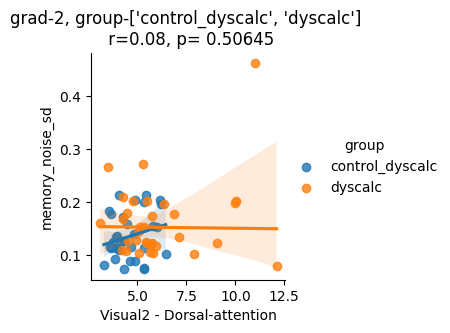

In [13]:
y_var = 'memory_noise_sd' #'perceptual_noise_sd' # 'Percent Correct'# _unbiased 'memory_noise_sd_unbiased
x_var = 'Visual2 - Dorsal-attention'
n_grad = 2

group = ['control_dyscalc','dyscalc' ] #'all' # 'control_miguel'

import pingouin
tmp = tmp = df_comb[df_comb['group'].isin(group)] if group != 'all' else df_comb #.drop(46, level='subject') # sub-46 drives effect !
cor = pingouin.corr(tmp[y_var], tmp[x_var], method = 'spearman') # shepherd,spearman,pearson || defautl: two -sided & pearson 
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)

fig = sns.lmplot(x=x_var, y=y_var, data=tmp,height=3, robust=True, hue='group') #  hue='group',
fig.set(title=f'grad-{n_grad}, group-{group} \n r={r_}, p= {p}' ) 

# pearson got effect but only when sub-46 is included --> not robust to outliers

## prelim results:

without dyscalc-group-biased effect for memory_noise no correlation survives 